BASE: C:\Users\User\Downloads
Found POS files: 3
Example files: ['C:\\Users\\User\\Downloads\\campus_road\\campus_road_pos.csv', 'C:\\Users\\User\\Downloads\\climbing_gym\\climbinggym_pos.csv', 'C:\\Users\\User\\Downloads\\lab_building\\lab_building_pos.csv']
OK: campus_road_pos.csv -> 154 clips
OK: climbinggym_pos.csv -> 336 clips
OK: lab_building_pos.csv -> 403 clips

Feature table: (893, 9)


,speed_mean,speed_std,yaw_abs_p90,clear_p10,cadence,t_start_s,t_end_s,scene,src
0,0.737244,1.814310,971.371439,-5.000000e-07,150.501672,0.0,2.99,campus_road,campus_road_pos.csv
1,0.529330,0.376725,894.914159,-6.800000e-05,150.501672,1.5,4.49,campus_road,campus_road_pos.csv
2,0.695045,0.445203,715.635846,-4.300000e-05,130.434783,3.0,5.99,campus_road,campus_road_pos.csv



Clips by scene_type:
scene_type
indoor     739
outdoor    154
Name: count, dtype: int64

Class counts (global thresholds):
 label
normal        366
fast          195
slow          156
sharp_turn     90
dragging       86
Name: count, dtype: int64

Leave-campus_road-out
              precision    recall  f1-score   support

    dragging       1.00      1.00      1.00         7
        fast       1.00      1.00      1.00        61
      normal       1.00      1.00      1.00        64
  sharp_turn       1.00      1.00      1.00         8
        slow       1.00      1.00      1.00        14

    accuracy                           1.00       154
   macro avg       1.00      1.00      1.00       154
weighted avg       1.00      1.00      1.00       154


Leave-climbing_gym-out
              precision    recall  f1-score   support

    dragging       1.00      1.00      1.00        31
        fast       0.96      1.00      0.98        24
      normal       1.00      0.99      1.00       119


label,dragging,fast,normal,sharp_turn,slow
scene,,,,,
campus_road,8,60,63,9,14
climbing_gym,32,34,142,41,87
lab_building,46,101,161,40,55



GLOBAL thresholds (overview only; derived from full dataset):
{'fast_thr(speed_mean, 75th)': 78.4117613892185, 'slow_thr(speed_mean, 25th)': 11.796150591280616, 'turn_thr(yaw_abs_p90, >=90th or 60)': 974.0276430034095, 'drag_thr(clear_p10, 10th)': -0.00159130000007496}


<Figure size 640x480 with 0 Axes>

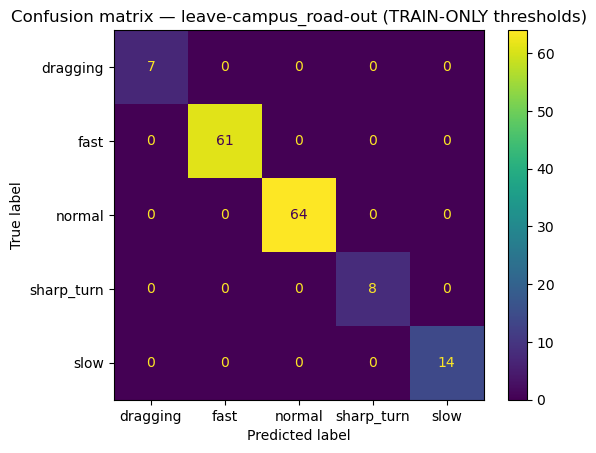


Top features (importance) — leave-campus_road-out:
 yaw_abs_p90    0.312612
speed_mean     0.308480
clear_p10      0.264645
speed_std      0.101720
cadence        0.012543
dtype: float64 



<Figure size 640x480 with 0 Axes>

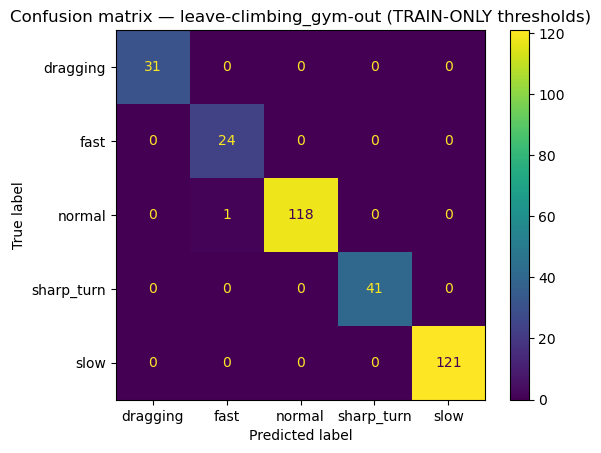


Top features (importance) — leave-climbing_gym-out:
 speed_mean     0.318598
yaw_abs_p90    0.300692
clear_p10      0.262157
speed_std      0.094959
cadence        0.023593
dtype: float64 



<Figure size 640x480 with 0 Axes>

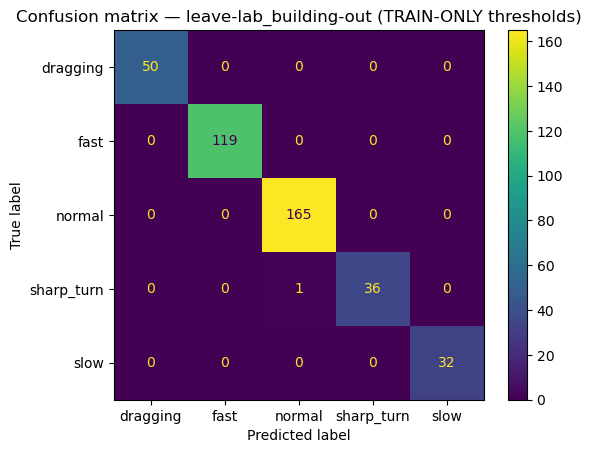


Top features (importance) — leave-lab_building-out:
 yaw_abs_p90    0.320458
speed_mean     0.290120
clear_p10      0.259783
speed_std      0.112869
cadence        0.016770
dtype: float64 


Macro/micro/accuracy per fold:


,fold,precision,recall,f1-score,support
accuracy,leave-campus_road-out,1.000000,1.000000,1.000000,1.000000
macro avg,leave-campus_road-out,1.000000,1.000000,1.000000,154.000000
weighted avg,leave-campus_road-out,1.000000,1.000000,1.000000,154.000000
accuracy,leave-climbing_gym-out,0.997024,0.997024,0.997024,0.997024
macro avg,leave-climbing_gym-out,0.992000,0.998319,0.995074,336.000000
weighted avg,leave-climbing_gym-out,0.997143,0.997024,0.997048,336.000000
accuracy,leave-lab_building-out,0.997519,0.997519,0.997519,0.997519
macro avg,leave-lab_building-out,0.998795,0.994595,0.996656,403.000000
weighted avg,leave-lab_building-out,0.997534,0.997519,0.997505,403.000000



Saved results to: C:\Users\User\outputs\results_exports
Files:
 - per_scene_class_counts_GLOBAL.csv
 - looo_reports_TRAINONLY.csv
 - looo_predictions_TRAINONLY.csv
 - looo_thresholds_TRAINONLY.csv


In [17]:
# HSC4D Pipeline 
# 1) Locate the HSC4D dataset folder
# 2) Find all per-scene position CSV files (*_pos.csv)
# 3) Define helper functions for column detection, time handling, windowing, and feature extraction
# 4) Extract clip-level (window-level) features from each scene
# 5) Create GLOBAL weak style labels (for overview counts only)
# 6) Train and evaluate a RF using LOSO with TRAIN-ONLY thresholds
# 7) Export clip-level features table to outputs/hsc4d_clip_features.csv

# Import required libraries: os/glob/pathlib for file paths and searching for CSV files, numpy/pandas for numeric and table handling, scipy.signal for peak detection and smoothing and sklearn for model, scaling and evaluation metrics

import os, glob, warnings
warnings.filterwarnings("ignore")  
import numpy as np
import pandas as pd
from scipy.signal import find_peaks, savgol_filter
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report

from pathlib import Path

# 1. Locate HSC4D dataset (Downloads-friendly; no hard-coded personal paths)
# Expected folder layout (either): Downloads/campus_road/, Downloads/climbing_gym/ and Downloads/lab_building/ or Downloads/HSC4D/campus_road/, Downloads/HSC4D/climbing_gym/ and Downloads/HSC4D/lab_building/

downloads = Path.home() / "Downloads"
cand1 = downloads
cand2 = downloads / "HSC4D"

def _looks_like_hsc4d(p: Path) -> bool:
    return (p / "campus_road").is_dir() and (p / "climbing_gym").is_dir() and (p / "lab_building").is_dir()

if _looks_like_hsc4d(cand1):
    BASE = str(cand1)
elif _looks_like_hsc4d(cand2):
    BASE = str(cand2)
else:
    raise FileNotFoundError(
        "HSC4D dataset not found.\n\n"
        "Please download and extract the dataset so these folders exist:\n"
        "  Downloads/campus_road/\n"
        "  Downloads/climbing_gym/\n"
        "  Downloads/lab_building/\n\n"
        "OR place them inside:\n"
        "  Downloads/HSC4D/\n"
    )

BASE = str(Path(BASE).resolve())
print("BASE:", BASE)

# 2. Find all per-scene position CSV files (*_pos.csv)

pos_files = [str(p) for p in Path(BASE).rglob("*_pos.csv")]
pos_files.sort()

print("Found POS files:", len(pos_files))
print("Example files:", pos_files[:3])

if not pos_files:
    raise SystemExit("No *_pos.csv found. Check that the .rar files were extracted correctly.")

# 3. Helper functions to automatically find pelvis and foot columns, build time axis, pick vertical axis and window each scene to compute the 5 kinematic features (speed_mean, speed_std, yaw_abs_p90, clear_p10, cadence)

def _find_xyz_columns(df, name_hints):
    """
    Find X/Y/Z column names for a body part (pelvis/left foot/right foot).
    The CSV headers can vary, so we search using 'name_hints' (e.g., 'Pelvis', 'LeftFoot').
    Returns a dict: {'x': <col>, 'y': <col>, 'z': <col>} (may contain None if not found).
    """
    cols = list(df.columns)
    lower = [c.lower() for c in cols]

    # Find columns that contain any hint (case-insensitive)
    cand_idx = [i for i, c in enumerate(lower) if any(h.lower() in c for h in name_hints)]
    cand_cols = [cols[i] for i in cand_idx]

    # Choose the best column for each axis (x/y/z)
    def pick(axis):
        # Prefer suffix patterns like ".x" or "_x"
        for c in cand_cols:
            cl = c.lower()
            if cl.endswith("." + axis) or cl.endswith("_" + axis):
                return c
        # Fall back to any column that contains the axis letter
        for c in cand_cols:
            if axis in c.lower():
                return c
        return None

    return {"x": pick("x"), "y": pick("y"), "z": pick("z")}

def _get_time(df):
    """
    Return a time vector for the CSV.
    If a time column exists (e.g., time/timestamp), use it.
    Otherwise assume 60 Hz and create a synthetic time axis.
    """
    for cand in ["time", "Time", "timestamp", "Timestamp", "t", "frame_time", "frameTime"]:
        if cand in df.columns:
            t = pd.to_numeric(df[cand], errors="coerce").to_numpy()
            dt = np.diff(t[np.isfinite(t)])
            # If the time looks valid (positive step), use it
            if len(dt) and np.nanmedian(dt) > 0:
                return t
    return np.arange(len(df)) / 60.0

# Infer which axis is vertical by comparing pelvis height vs foot height
def _choose_up(df, pel, lf, rf):
    """
    Automatically detect which axis is vertical ("up").
    Heuristic: the vertical axis should place pelvis consistently above feet.
    """
    scores = {}
    for ax in ("x", "y", "z"):
        pc, lc, rc = pel.get(ax), lf.get(ax), rf.get(ax)
        if pc and lc and rc:
            P = pd.to_numeric(df[pc], errors="coerce").to_numpy()
            L = pd.to_numeric(df[lc], errors="coerce").to_numpy()
            R = pd.to_numeric(df[rc], errors="coerce").to_numpy()
            scores[ax] = np.nanmean(P) - np.nanpercentile(np.minimum(L, R), 5)
    return max(scores, key=scores.get) if scores else "y"

# Compute the 5 interpretable kinematic features for one window
def _features_from_window(t, pelvis_xy, yaw_deg, lf_h, rf_h):
    """
    Compute 5 interpretable kinematic features for ONE window:
      - speed_mean: mean ground-plane speed
      - speed_std: speed variability
      - yaw_abs_p90: 90th percentile absolute yaw rate (turning intensity)
      - clear_p10: 10th percentile of min foot clearance (lower = more dragging)
      - cadence: steps/min estimated from foot height peaks
    """
    # Ground-plane speed from pelvis position derivatives
    vx = np.gradient(pelvis_xy[:, 0], t)
    vy = np.gradient(pelvis_xy[:, 1], t)
    speed = np.sqrt(vx**2 + vy**2)
    yaw_abs = np.abs(yaw_deg)
    
    # Foot clearance proxy: subtract low-percentile height (per foot) then take min across feet
    def clr(y):
        return y - np.nanpercentile(y, 5)

    min_clear = np.minimum(clr(lf_h), clr(rf_h))  # take the lower of the two feet

    # Estimate cadence by counting peaks in foot height signals
    if len(t) > 1:
        dt = np.nanmedian(np.diff(t))
        min_dist = max(1, int(0.3 / dt))  # enforce at least ~0.3s between peaks
    else:
        min_dist = 1

    pL, _ = find_peaks(lf_h, distance=min_dist)
    pR, _ = find_peaks(rf_h, distance=min_dist)
    
    # Rough step estimate: average peak counts from left and right
    steps = (len(pL) + len(pR)) / 2.0

    duration = max(t[-1] - t[0], 1e-6)  # avoid divide by zero
    cadence = float(np.clip((steps / duration) * 60.0, 40, 200))  # steps/min clamped

    return {
        "speed_mean":  float(np.nanmean(speed)),                 # average walking speed
        "speed_std":   float(np.nanstd(speed)),                  # speed variability
        "yaw_abs_p90": float(np.nanpercentile(yaw_abs, 90)),     # turning intensity
        "clear_p10":   float(np.nanpercentile(min_clear, 10)),   # low foot clearance
        "cadence":     cadence,                                  # steps per minute
    }

# For one *_pos.csv file to load data, compute yaw rate and clearance, window it and return features per clip
def _extract_clip_features(path, win_s=3.0, hop_s=1.5):
    """
    Load one *_pos.csv and extract window-level features:
    - detect pelvis + left/right foot columns
    - build time axis (or assume 60 Hz)
    - infer vertical axis (up) and use the other two as ground plane axes
    - ssmooth pelvis ground-plane positions
    - compute yaw rate from smoothed heading
    - slide a 3.0s window with a 1.5s hop and compute 5 features per window
    Returns: DataFrame of clip/window features for this file.
    """
    df = pd.read_csv(path, engine="python")

    pel = _find_xyz_columns(df, ["Hips", "Pelvis", "Root"])
    lf  = _find_xyz_columns(df, ["LeftFoot", "LeftAnkle", "LeftToe", "L_Foot", "LToe"])
    rf  = _find_xyz_columns(df, ["RightFoot", "RightAnkle", "RightToe", "R_Foot", "RToe"])

    if not any(pel.values()) or not any(lf.values()) or not any(rf.values()):
        raise ValueError("Missing pelvis/foot columns. First 12 cols: " + ", ".join(df.columns[:12]))

    t = _get_time(df)
    dt = np.nanmedian(np.diff(t)) if len(t) > 1 else 1 / 60.0
    fps = 1.0 / dt

    up = _choose_up(df, pel, lf, rf)
    horiz = [ax for ax in ("x", "y", "z") if ax != up]

    # Convert needed columns tonumeric arrays
    px_raw = pd.to_numeric(df[pel[horiz[0]]], errors="coerce").to_numpy()
    pz_raw = pd.to_numeric(df[pel[horiz[1]]], errors="coerce").to_numpy()
    lf_h   = pd.to_numeric(df[lf[up]], errors="coerce").to_numpy()
    rf_h   = pd.to_numeric(df[rf[up]], errors="coerce").to_numpy()

    # Smooth pelvis ground-plane positions before differentiating (reduces noise)
    w = max(5, int(round(0.25 * fps)))
    if w % 2 == 0:
        w += 1  
    px = savgol_filter(px_raw, w, 2, mode="interp") if w < len(px_raw) else px_raw
    pz = savgol_filter(pz_raw, w, 2, mode="interp") if w < len(pz_raw) else pz_raw

    # Compute heading from velocity, smooth heading and then differentiate to get yaw rate
    vx = np.gradient(px, t)
    vz = np.gradient(pz, t)
    heading = np.unwrap(np.arctan2(vx, vz))  # unwrap avoids angle jumps at +/-pi

    # Convert window/hop seconds into sample counts
    w_h = max(5, int(round(0.40 * fps)))
    w_h += (w_h % 2 == 0)  # make odd
    heading_s = savgol_filter(heading, w_h, 2, mode="interp") if w_h < len(heading) else heading
    yaw_deg = np.degrees(np.gradient(heading_s, t))  # yaw rate in deg/s

    win = max(2, int(round(win_s / dt)))
    hop = max(1, int(round(hop_s / dt)))

    feats = []
    for a in range(0, len(t) - win, hop):
        b = a + win

        f = _features_from_window(
            t[a:b],
            np.stack([px[a:b], pz[a:b]], 1),   # pelvis ground-plane XY
            yaw_deg[a:b],
            lf_h[a:b],
            rf_h[a:b]
        )

        # Add metadata for traceability
        f["t_start_s"], f["t_end_s"] = float(t[a]), float(t[b - 1])
        f["scene"] = os.path.basename(os.path.dirname(path))  # folder name = scene
        f["src"]   = os.path.basename(path)                   # filename
        feats.append(f)

    return pd.DataFrame(feats)

# 4. Extract features for all scenes
all_feats = []
for path in pos_files:
    try:
        df = _extract_clip_features(path, win_s=3.0, hop_s=1.5)
        all_feats.append(df)
        print(f"OK: {os.path.basename(path)} -> {len(df)} clips")
    except Exception as e:
        print(f"SKIP {os.path.basename(path)}: {e}")
        continue

if not all_feats:
    raise SystemExit("No features extracted. Inspect CSV headers.")

data = pd.concat(all_feats, ignore_index=True)
print("\nFeature table:", data.shape)

# Show first 3 rows in notebook 
try:
    from IPython.display import display
    display(data.head(3))
except Exception:
    print(data.head(3))

# Create a indoor/outdoor scene tag for reporting
scene_kind = {
    "campus_road": "outdoor",
    "lab_building": "indoor",
    "climbing_gym": "indoor"
}
data["scene_type"] = data["scene"].map(scene_kind).fillna("unknown")

print("\nClips by scene_type:")
print(data["scene_type"].value_counts())

# 5. GLOBAL weak labels (overview counts only)
# These thresholds are computed on the full dataset for summary tables.
# The actual LOSO evaluation below recomputes thresholds on TRAIN ONLY per fold.
fast_thr = data["speed_mean"].quantile(0.75)              # top 25% speed_mean
slow_thr = data["speed_mean"].quantile(0.25)              # bottom 25% speed_mean
turn_thr = max(data["yaw_abs_p90"].quantile(0.90), 60.0)  # top 10% yaw_abs_p90 OR >= 60 deg/s
drag_thr = data["clear_p10"].quantile(0.10)               # bottom 10% clear_p10

def _make_label(r):
    """
    Create a multi-tag weak label based on the current thresholds.
    Example output: "sharp_turn”, “fast" or "normal".
    Note: This uses whatever threshold values are currently set (global or fold-specific).
    """
    tags = []
    if r["yaw_abs_p90"] >= turn_thr: tags.append("sharp_turn")
    if r["clear_p10"]   <= drag_thr: tags.append("dragging")
    if r["speed_mean"]  >= fast_thr: tags.append("fast")
    if r["speed_mean"]  <= slow_thr: tags.append("slow")
    return ",".join(tags) if tags else "normal"

def _collapse(lbl):
    """
    Collapse multi-tag labels to a single class using priority:
    sharp_turn > dragging > fast > slow > normal
    """
    s = set((lbl or "").split(","))
    if "sharp_turn" in s: return "sharp_turn"
    if "dragging" in s:   return "dragging"
    if "fast" in s:       return "fast"
    if "slow" in s:       return "slow"
    return "normal"

# Apply GLOBAL overview labels (used only for dataset summary / counts)
data["auto_label"] = data.apply(_make_label, axis=1)
data["label"] = data["auto_label"].apply(_collapse)
print("\nClass counts (global thresholds):\n", data["label"].value_counts())

# 6) LOSO training and evaluation with TRAIN-ONLY thresholds
# For each fold: compute thresholds using TRAIN scenes only, label both train and test using those thresholds and train RF on 5 features and evaluate on the held-out scene
feat_cols = ["speed_mean", "speed_std", "yaw_abs_p90", "clear_p10", "cadence"]
scenes = sorted(data.scene.unique())

for scene in scenes:
    # Train = all scenes except the held-out one; Test = held-out scene
    train_df = data[data.scene != scene].copy()
    test_df  = data[data.scene == scene].copy()

    # Compute thresholds on TRAIN ONLY (prevents test-scene leakage in labeling rules)
    fast_thr = train_df["speed_mean"].quantile(0.75)
    slow_thr = train_df["speed_mean"].quantile(0.25)
    turn_thr = max(train_df["yaw_abs_p90"].quantile(0.90), 60.0)
    drag_thr = train_df["clear_p10"].quantile(0.10)

    # Label both train and test using the TRAIN-derived thresholds
    train_df["auto_label"] = train_df.apply(_make_label, axis=1)
    train_df["label"] = train_df["auto_label"].apply(_collapse)
    test_df["auto_label"]  = test_df.apply(_make_label, axis=1)
    test_df["label"] = test_df["auto_label"].apply(_collapse)

    # Remove rare classes in training to avoid unstable folds
    rare = set(train_df["label"].value_counts()[lambda s: s < 3].index)
    if rare:
        train_df = train_df[~train_df["label"].isin(rare)]
        test_df  = test_df[~test_df["label"].isin(rare)]

    # Skip fold if there is not enough data to train/evaluate
    if len(test_df) == 0 or train_df["label"].nunique() < 2:
        print(f"\nLeave-{scene}-out skipped (not enough data)")
        continue

    # Prepare arrays for model training/testing
    Xtr, ytr = train_df[feat_cols].to_numpy(), train_df["label"].to_numpy()
    Xte, yte = test_df[feat_cols].to_numpy(),  test_df["label"].to_numpy()

    # Pipeline: standardise features then train RF
    clf = make_pipeline(
        StandardScaler(),
        RandomForestClassifier(
            n_estimators=400,
            random_state=42,
            class_weight="balanced"
        )
    )

    # Fit model and evaluate predictions
    clf.fit(Xtr, ytr)
    pred = clf.predict(Xte)

    print(f"\nLeave-{scene}-out")
    print(classification_report(yte, pred, zero_division=0))

# 7. Save outputs
# Save the final clip-level dataset to a CSV file for reproducibility
OUT_DIR = Path.cwd() / "outputs"
OUT_DIR.mkdir(exist_ok=True)

out_csv = OUT_DIR / "hsc4d_clip_features.csv"
data.to_csv(out_csv, index=False)
print("\nSaved:", out_csv)

# Results artefacts
# - Reads:  outputs/hsc4d_clip_features.csv
# - Saves:  outputs/results_exports/

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Optional: notebook-friendly display fallback
try:
    from IPython.display import display
except Exception:
    display = print

# Load features produced by the pipeline
FEATURES_CSV = Path.cwd() / "outputs" / "hsc4d_clip_features.csv"
if not FEATURES_CSV.is_file():
    raise FileNotFoundError(
        f"Cannot find: {FEATURES_CSV}\n\n"
        "Run the pipeline first to generate outputs/hsc4d_clip_features.csv"
    )

data = pd.read_csv(FEATURES_CSV)
print("Loaded:", FEATURES_CSV)
print("Shape:", data.shape)
print("Columns:", list(data.columns))

# Ensure the minimum required columns exist in the features CSV
required_cols = {"scene", "src", "t_start_s", "t_end_s",
                 "speed_mean","speed_std","yaw_abs_p90","clear_p10","cadence"}
missing = sorted(list(required_cols - set(data.columns)))
if missing:
    raise ValueError(f"Missing required columns in CSV: {missing}")

# If scene_type or label columns are missing, recreate them
if "scene_type" not in data.columns:
    scene_kind = {
        "campus_road": "outdoor",
        "lab_building": "indoor",
        "climbing_gym": "indoor"
    }
    data["scene_type"] = data["scene"].map(scene_kind).fillna("unknown")

# If global labels aren't present, create them (overview only)
if "label" not in data.columns:
    fast_thr_g = data["speed_mean"].quantile(0.75)
    slow_thr_g = data["speed_mean"].quantile(0.25)
    turn_thr_g = max(data["yaw_abs_p90"].quantile(0.90), 60.0)
    drag_thr_g = data["clear_p10"].quantile(0.10)

    def _make_label_global(r):
        # Multi-tag weak labels using GLOBAL thresholds
        tags = []
        if r["yaw_abs_p90"] >= turn_thr_g: tags.append("sharp_turn")
        if r["clear_p10"]   <= drag_thr_g: tags.append("dragging")
        if r["speed_mean"]  >= fast_thr_g: tags.append("fast")
        if r["speed_mean"]  <= slow_thr_g: tags.append("slow")
        return ",".join(tags) if tags else "normal"

    def _collapse_global(lbl):
        # Collapse multi-tag labels into ONE class using priority order
        s = set((lbl or "").split(","))
        if "sharp_turn" in s: return "sharp_turn"
        if "dragging" in s:   return "dragging"
        if "fast" in s:       return "fast"
        if "slow" in s:       return "slow"
        return "normal"

    data["auto_label"] = data.apply(_make_label_global, axis=1)
    data["label"] = data["auto_label"].apply(_collapse_global)

# 1. Helper functions for TRAIN-ONLY weak labels (used inside LOSO folds)
def _make_label_row(r, fast_thr, slow_thr, turn_thr, drag_thr):
    """Create multi-tag weak label for one row using the provided (train-only) thresholds."""
    tags = []
    if r["yaw_abs_p90"] >= turn_thr: tags.append("sharp_turn")
    if r["clear_p10"]   <= drag_thr: tags.append("dragging")
    if r["speed_mean"]  >= fast_thr: tags.append("fast")
    if r["speed_mean"]  <= slow_thr: tags.append("slow")
    return ",".join(tags) if tags else "normal"

def _collapse_label(lbl):
    """Collapse multi-tag label into a single class using priority order."""
    s = set((lbl or "").split(","))
    if "sharp_turn" in s: return "sharp_turn"
    if "dragging" in s:   return "dragging"
    if "fast" in s:       return "fast"
    if "slow" in s:       return "slow"
    return "normal"

def _apply_fold_labels(df, fast_thr, slow_thr, turn_thr, drag_thr):
    """
    Apply TRAIN-derived thresholds to a dataframe and output:
    - auto_label_fold (multi-tag)
    - label_fold (single class after priority collapse)
    """
    auto = df.apply(lambda r: _make_label_row(r, fast_thr, slow_thr, turn_thr, drag_thr), axis=1)
    out = df.copy()
    out["auto_label_fold"] = auto
    out["label_fold"] = out["auto_label_fold"].apply(_collapse_label)
    return out

# 2. Dataset summary
print("\nClips by scene:\n", data["scene"].value_counts(), "\n")
print("Clips by scene_type:\n", data["scene_type"].value_counts(), "\n")
print("Class counts (GLOBAL overview labels):\n", data["label"].value_counts(), "\n")

per_scene_table_global = (
    data.groupby(["scene", "label"]).size().unstack(fill_value=0).sort_index()
)
print("Per-scene class counts (GLOBAL overview labels):\n")
display(per_scene_table_global)

# 3. Record the GLOBAL thresholds used for overview counts
print("\nGLOBAL thresholds (overview only; derived from full dataset):")
print({
    "fast_thr(speed_mean, 75th)": float(data["speed_mean"].quantile(0.75)),
    "slow_thr(speed_mean, 25th)": float(data["speed_mean"].quantile(0.25)),
    "turn_thr(yaw_abs_p90, >=90th or 60)": float(max(data["yaw_abs_p90"].quantile(0.90), 60.0)),
    "drag_thr(clear_p10, 10th)": float(data["clear_p10"].quantile(0.10)),
})

# 4. LOSO evaluation with TRAIN-ONLY thresholds,  confusion matrices and exports
feat_cols = ["speed_mean","speed_std","yaw_abs_p90","clear_p10","cadence"]
scenes = sorted(data["scene"].unique())

all_fold_reports = []       # classification reports per fold (as dataframes)
all_preds = []              # per-clip predictions for each fold
all_fold_thresholds = []    # train-only threshold values per fold

for scene in scenes:
    # Split data: train = all other scenes, test = held-out scene
    base_train = data[data.scene != scene].copy()
    base_test  = data[data.scene == scene].copy()

    if len(base_test) == 0:
        print(f"\nLeave-{scene}-out skipped (no test clips)")
        continue

    # Compute thresholds on TRAIN ONLY (prevents leakage)
    fast_thr = base_train["speed_mean"].quantile(0.75)
    slow_thr = base_train["speed_mean"].quantile(0.25)
    turn_thr = max(base_train["yaw_abs_p90"].quantile(0.90), 60.0)
    drag_thr = base_train["clear_p10"].quantile(0.10)

    # Record threshold values for this fold
    all_fold_thresholds.append({
        "fold": f"leave-{scene}-out",
        "fast_thr_75_speed_mean": float(fast_thr),
        "slow_thr_25_speed_mean": float(slow_thr),
        "turn_thr_max_90_or_60_yaw_abs_p90": float(turn_thr),
        "drag_thr_10_clear_p10": float(drag_thr),
        "held_out_scene": scene
    })

    # Apply train-derived thresholds to both train and test
    train_df = _apply_fold_labels(base_train, fast_thr, slow_thr, turn_thr, drag_thr)
    test_df  = _apply_fold_labels(base_test,  fast_thr, slow_thr, turn_thr, drag_thr)

    # Drop rare classes in TRAIN for stability 
    rare = set(train_df["label_fold"].value_counts()[lambda s: s < 3].index)
    if rare:
        train_df = train_df[~train_df["label_fold"].isin(rare)]
        test_df  = test_df[~test_df["label_fold"].isin(rare)]

    # Skip fold if it becomes invalid after filtering
    if len(test_df) == 0 or train_df["label_fold"].nunique() < 2:
        print(f"\nLeave-{scene}-out skipped (not enough data after rare-drop)")
        continue

    # Train and evaluate RF on 5 interpretable features
    Xtr, ytr = train_df[feat_cols].to_numpy(), train_df["label_fold"].to_numpy()
    Xte, yte = test_df[feat_cols].to_numpy(),  test_df["label_fold"].to_numpy()

    clf = make_pipeline(
        StandardScaler(),
        RandomForestClassifier(n_estimators=400, random_state=42, class_weight="balanced")
    )
    clf.fit(Xtr, ytr)
    pred = clf.predict(Xte)

    # Save per-clip predictions for reproducibility
    fold_df = test_df[["scene","scene_type","t_start_s","t_end_s","src"]].copy()
    fold_df["y_true"] = yte
    fold_df["y_pred"] = pred
    fold_df["fold"] = f"leave-{scene}-out"
    all_preds.append(fold_df)

    # Save classification report for this fold
    rep = classification_report(yte, pred, output_dict=True, zero_division=0)
    rep_df = pd.DataFrame(rep).T
    rep_df.insert(0, "fold", f"leave-{scene}-out")
    all_fold_reports.append(rep_df)

    # Plot confusion matrix for this fold
    labels = sorted(np.unique(np.concatenate([yte, pred])))
    cm = confusion_matrix(yte, pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    plt.figure()
    disp.plot(values_format="d")
    plt.title(f"Confusion matrix — leave-{scene}-out (TRAIN-ONLY thresholds)")
    plt.show()

    # Print feature importances (model interpretability)
    rf = clf.named_steps["randomforestclassifier"]
    importances = pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=False)
    print(f"\nTop features (importance) — leave-{scene}-out:\n", importances, "\n")

# Combine fold outputs into single tables
reports_df = pd.concat(all_fold_reports, axis=0) if all_fold_reports else pd.DataFrame()
preds_df   = pd.concat(all_preds, axis=0) if all_preds else pd.DataFrame()
thr_df     = pd.DataFrame(all_fold_thresholds)

# Print compact summary rows
if not reports_df.empty:
    print("\nMacro/micro/accuracy per fold:")
    display(reports_df.loc[reports_df.index.isin(["accuracy","macro avg","weighted avg"])])

# 7. Save exported artefacts into outputs/results_exports/
res_dir = Path.cwd() / "outputs" / "results_exports"
res_dir.mkdir(parents=True, exist_ok=True)

per_scene_table_global.to_csv(res_dir / "per_scene_class_counts_GLOBAL.csv")

if not reports_df.empty:
    reports_df.to_csv(res_dir / "looo_reports_TRAINONLY.csv", index=True)

if not preds_df.empty:
    preds_df.to_csv(res_dir / "looo_predictions_TRAINONLY.csv", index=False)

thr_df.to_csv(res_dir / "looo_thresholds_TRAINONLY.csv", index=False)

print(f"\nSaved results to: {res_dir}")
print("Files:")
print(" - per_scene_class_counts_GLOBAL.csv")
print(" - looo_reports_TRAINONLY.csv")
print(" - looo_predictions_TRAINONLY.csv")
print(" - looo_thresholds_TRAINONLY.csv")
